In [3]:
import pandas as pd
import seaborn as sns

In [4]:
tips = sns.load_dataset('tips')

In [5]:
tips.sample(7)

,total_bill,tip,sex,smoker,day,time,size
85,34.83,5.17,Female,No,Thur,Lunch,4
106,20.49,4.06,Male,Yes,Sat,Dinner,2
104,20.92,4.08,Female,No,Sat,Dinner,2
202,13.00,2.00,Female,Yes,Thur,Lunch,2
196,10.34,2.00,Male,Yes,Thur,Lunch,2
226,10.09,2.00,Female,Yes,Fri,Lunch,2
93,16.32,4.30,Female,Yes,Fri,Dinner,2


In [6]:
titanic = pd.read_csv('train.csv')

In [7]:
flights = sns.load_dataset('flights')

In [8]:
flights.sample(7)

,year,month,passengers
120,1959,Jan,360
81,1955,Oct,274
104,1957,Sep,404
25,1951,Feb,150
115,1958,Aug,505
13,1950,Feb,126
75,1955,Apr,269


In [9]:
iris = sns.load_dataset('iris')

In [10]:
iris.sample(7)

,sepal_length,sepal_width,petal_length,petal_width,species
111,6.4,2.7,5.3,1.9,virginica
3,4.6,3.1,1.5,0.2,setosa
23,5.1,3.3,1.7,0.5,setosa
5,5.4,3.9,1.7,0.4,setosa
129,7.2,3.0,5.8,1.6,virginica
124,6.7,3.3,5.7,2.1,virginica
53,5.5,2.3,4.0,1.3,versicolor


## 1. Scatterplot (Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

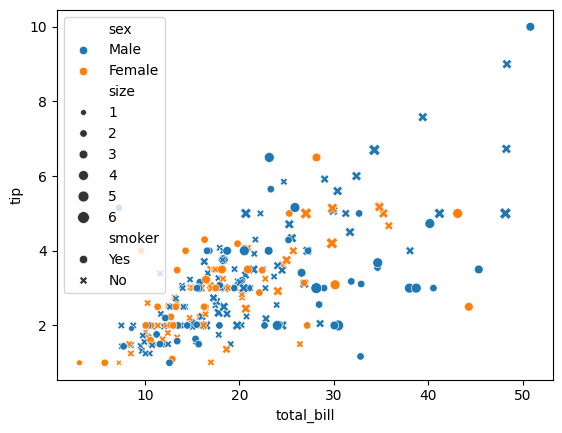

In [11]:
# sns.scatterplot(tips['total_bill'], tips['tip'], hue=df['sex'], style=df['smoker'], size=df['size'])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', style='smoker', size='size')

# hue - maps a variable to the color of the markers
# style - maps a variale to different shapes or markers
# size - maps a variable to the physical size of the markers

## 2. Bar Plot (Numerical - Categorical)

In [12]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Fare'>

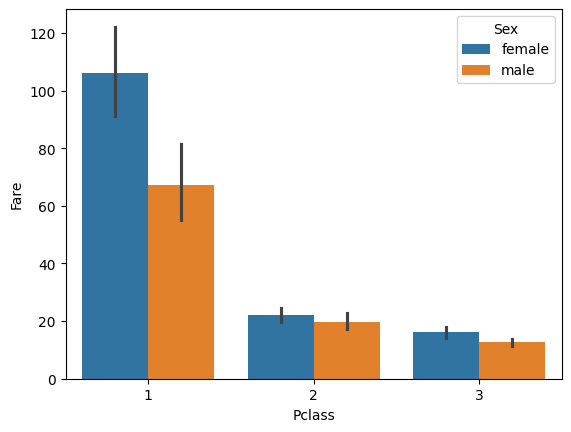

In [13]:
# sns.barplot(titanic['Pclass'],titanic['Age'],hue=titanic['Sex'])
sns.barplot(data=titanic, x='Pclass', y='Fare', hue='Sex') # keep CATEGORIES on X-AXIS and NUMERICAL VALUES on Y-AXIS!!!

# hue splits the Age classification of each Pclass further on the basis of Sex|

# The black line on top of each barplot shows us the 'CONFIDENCE INTERVAL'

## 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

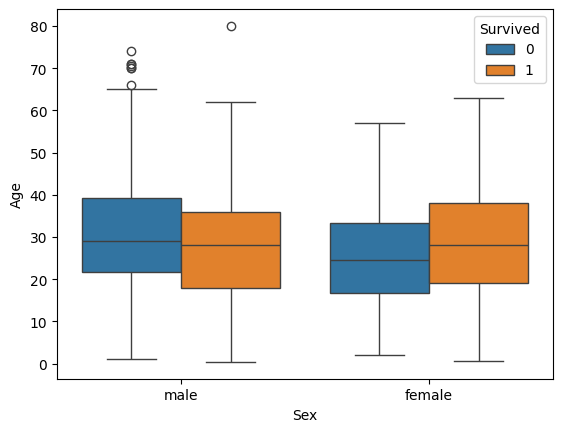

In [14]:
# sns.boxplot(titanic['Sex'],titanic['Age'],hue=titanic['Survived'])
sns.boxplot(data=titanic, x='Sex', y='Age', hue='Survived')

## 4. Distplot (Numerical - Categorical)

<Axes: xlabel='Age', ylabel='Density'>

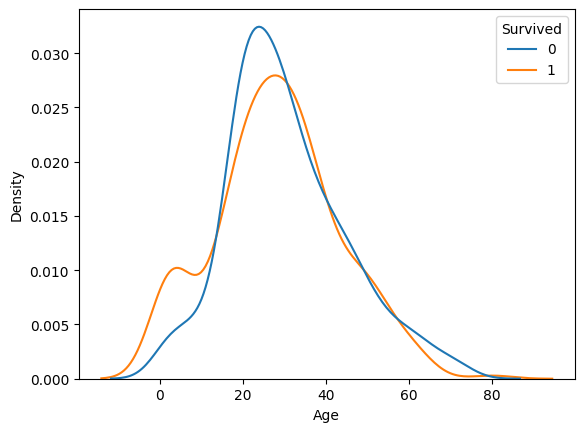

In [19]:
# sns.distplot(titanic[titanic['Survived']==0]['Age'],hist=False)
# sns.distplot(titanic[titanic['Survived']==1]['Age'],hist=False)

sns.kdeplot(data=titanic, x='Age', hue='Survived', common_norm=False)

<Axes: xlabel='Age', ylabel='Density'>

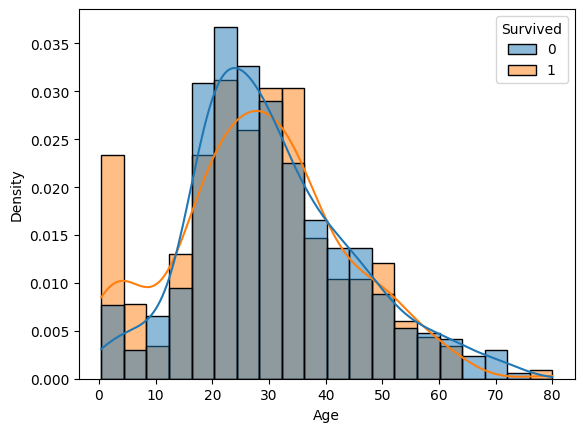

In [20]:
sns.histplot(data=titanic, x='Age', hue='Survived',kde=True, stat='density', common_norm=False)

# By setting common_norm=False, Seaborn calculates the density scale independently for each group. The blue group is normalized to an area of 1, and the orange group is separately normalized to an area of 1. This is critical here because it ensures that even though fewer people survived, the orange curve is scaled correctly so you can accurately compare its shape against the blue curve
# when stat='density' AND kde=True - we get the PDF and hence can calculate the probability of survival/non-survival of an age range

## 5. HeatMap (Categorical - Categorical)

In [21]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [23]:
pd.crosstab(titanic['Pclass'], titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

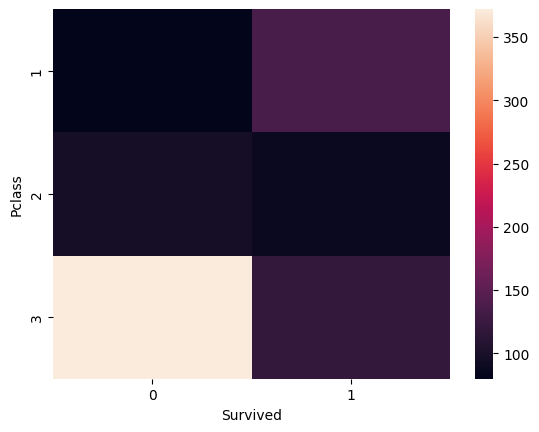

In [25]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

# Used to see if certain CATEGORIES are strongly tied to certain OUTCOMES?

In [35]:
print((titanic.groupby('Embarked')['Survived'].mean()*100))
print((titanic.groupby('Age')['Survived'].mean()*100))
print((titanic.groupby('Pclass')['Survived'].mean()*100))

# here, calculation of percentages of survived work using the 'Survived' because Survived spits values either 0 or 1 - so mean is (sum of survived column)/(total passengers in group) and numerator will be 1*(no. of survived) so we get the % of survived

# But had there been no such column which takes values only 0 and 1 then :-
# 1. Suppose the column has text: 'Survived' or 'Died'
# (df.groupby('Category')['Status'] == 'Survived').mean() * 100
# OR 
# 2. Gives the percentage break-up of ALL categories inside each group
# df.groupby('Category')['Status'].value_counts(normalize=True) * 100
# OR
# 3. Filter for 'Yes', count them, and divide by total group size
# df[df['Status'] == 'Yes'].groupby('Category').size() / df.groupby('Category').size() * 100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64
Age
0.42     100.0
0.67     100.0
0.75     100.0
0.83     100.0
0.92     100.0
         ...  
70.00      0.0
70.50      0.0
71.00      0.0
74.00      0.0
80.00    100.0
Name: Survived, Length: 88, dtype: float64
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## 6. ClusterMap (Categorical - Categorical)

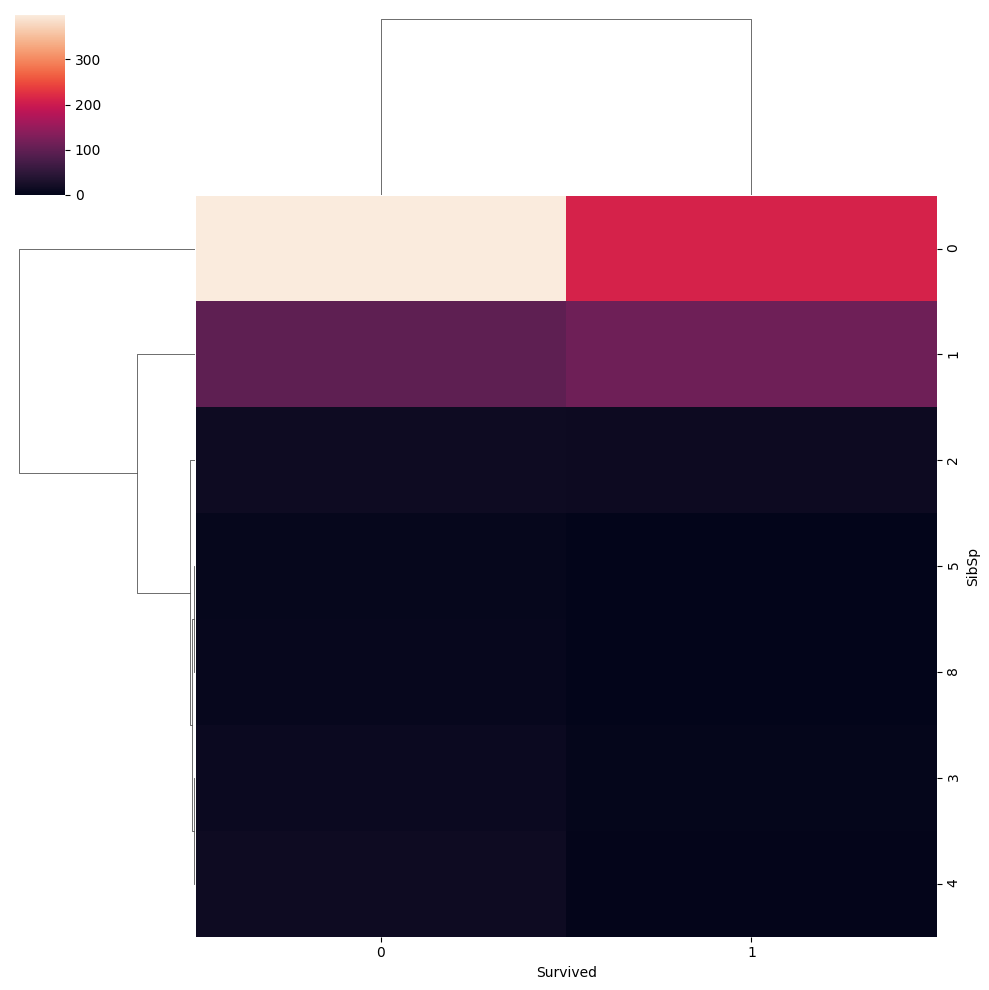

In [40]:
sns.clustermap(pd.crosstab(titanic['SibSp'],titanic['Survived']))

# Clustermap takes that exact same heatmap grid and reorders the rows and columns based on how statistically similar they are to one another. It groups similar categories side by side and attaches dendrograms.
# Dendrograms are tree structure drawn at the top or left of a clustermap - Categories that join together at lower, shorter branches are very similar to each other in their data patterns
# The height of the connection (or length of the branch lines) indicates how different two clusters are. Long branches joining two groups mean those groups have vastly different behavior patterns

## 7. Pairplot

In [41]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


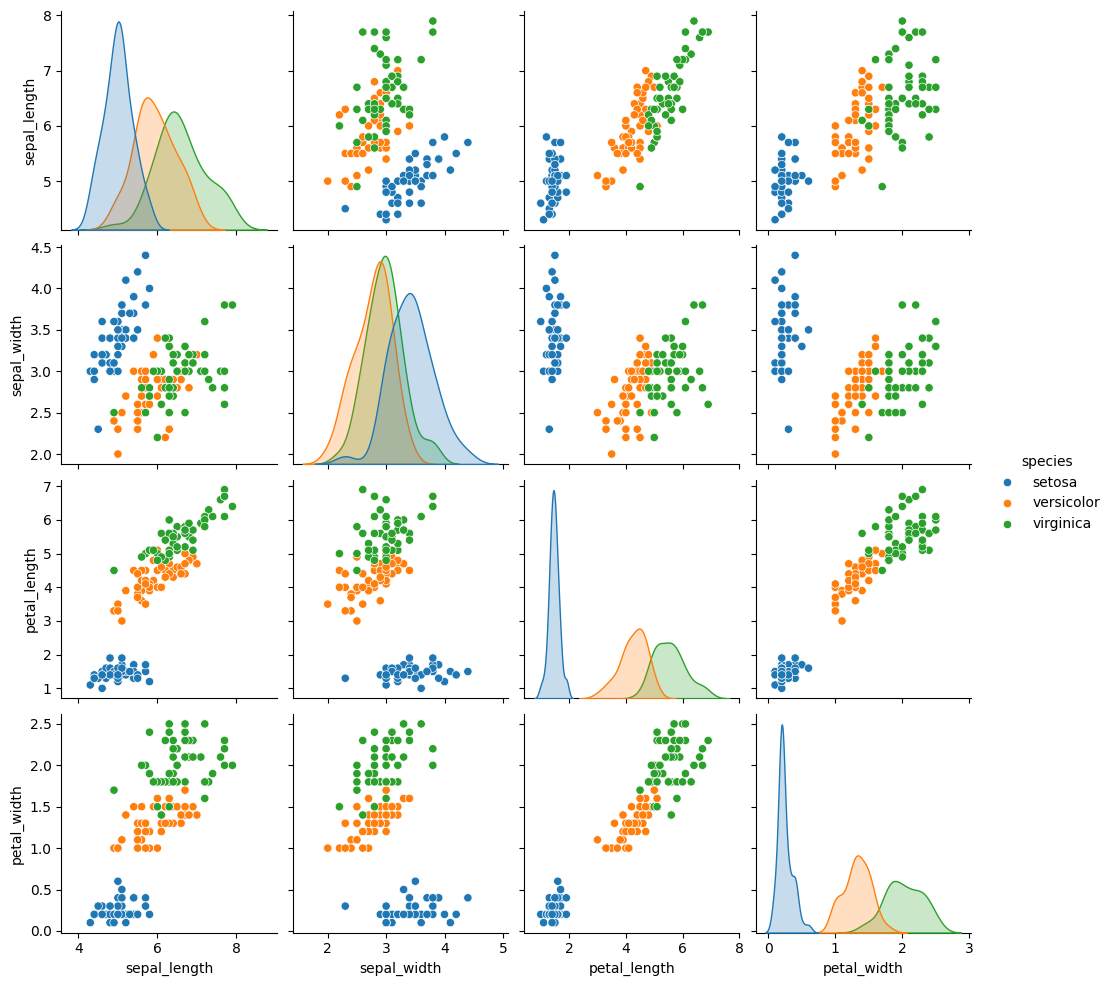

In [44]:
sns.pairplot(iris, hue='species')

# it gives scatterplot between all possible different columns, and if a column is paired with itself it gives us a histogram!

## 8. Lineplot (Numerical - Numerical)

Line plots should be used when the data on x-axis is TIME-BASED because time flows forward naturally without skipping or scrambling.
Line plots are made by plotting data points and joining them with straight lines; if there are multiple 'y' for a single 'x', average value of all y is used and the area around the line at that point is shaded to represent confidence interval

In [49]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [50]:
new = flights.groupby('year')['passengers'].sum().reset_index()

<Axes: xlabel='year', ylabel='passengers'>

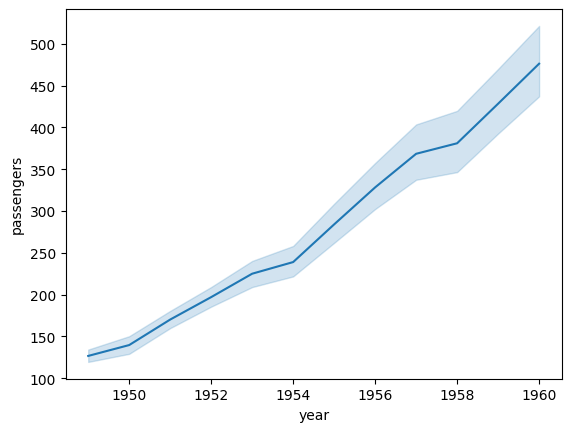

In [52]:
sns.lineplot(data=flights, x='year', y='passengers') # entire plot has confidence interval because each year has 12 values summed up for each month

In [85]:
flights

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121
...,...,...,...
139,1960,August,606
140,1960,September,508
141,1960,October,461
142,1960,November,390


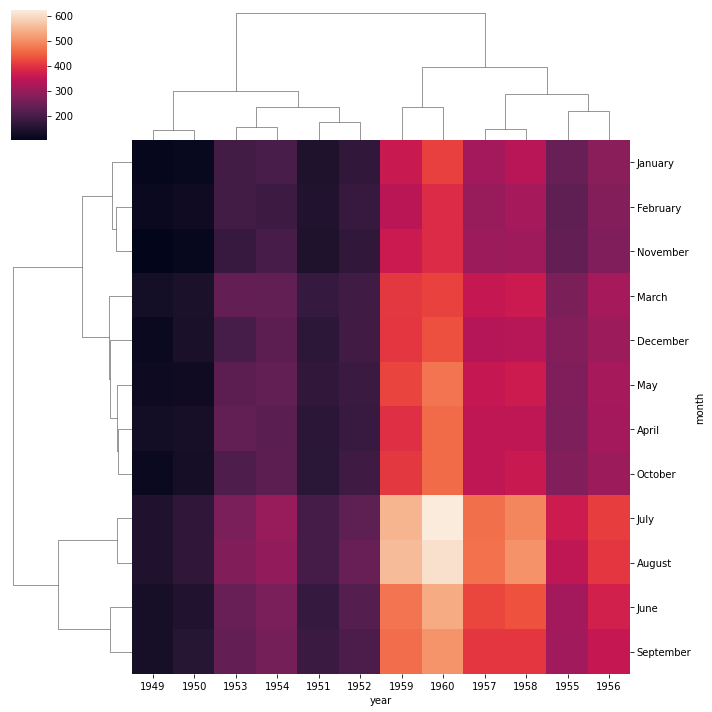

In [88]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))